# 04 - Gözetimli Makine Öğrenmesi
## Uydu Telemetri Anomali Tespiti

Segment bazlı özellik matrisini kullanarak gözetimli anomali tespiti modellerini eğitmek.

### Modeller:
1. Random Forest
2. Support Vector Machine
3. XGBoost
4. MLP


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, sys
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

sys.path.insert(0, '..')
sys.path.insert(0, os.path.join('..', 'src'))
from src.models.supervised import SupervisedAnomalyDetector
from metrics import compute_metrics, metrics_table, BENCHMARK_METRICS

print('Kütüphaneler, Model Sınıfı ve metrik modülü yüklendi.')

please install torch first
please install torch first
please install torch first
Kütüphaneler, Model Sınıfı ve metrik modülü yüklendi.


---
## Bölüm 1: Veri Hazırlama


In [2]:
# NB02 (ön işleme) çıktılarını yükle — resmi split, RobustScaler ölçekleme ve SMOTE
# orada (leakage-free) yapıldı; burada TEKRAR EDİLMEZ. Tek ön işleme kaynağı: NB02.
PROC = '../data/processed'
_Xtr = pd.read_parquet(f'{PROC}/X_train.parquet')   # RobustScaler + SMOTE'lu T eğitim
feature_cols = list(_Xtr.columns)
X_train_s = _Xtr.values
X_val_s  = pd.read_parquet(f'{PROC}/X_val.parquet').values    # RobustScaler + SMOTE'lu T validation
X_test_s = pd.read_parquet(f'{PROC}/X_test.parquet').values   # RobustScaler'lı resmi Ψ test
y_train_sm = pd.read_parquet(f'{PROC}/y_train.parquet')['anomaly']
y_val      = pd.read_parquet(f'{PROC}/y_val.parquet')['anomaly']
y_test     = pd.read_parquet(f'{PROC}/y_test.parquet')['anomaly']

print(f"NB02'den yüklendi — Train (SMOTE'lu T): {X_train_s.shape}, Val: {X_val_s.shape}, "
      f"Test Ψ: {X_test_s.shape}  ({len(feature_cols)} özellik, RobustScaler)")

NB02'den yüklendi — Train (SMOTE'lu T): (2164, 18), Val: (382, 18), Test Ψ: (529, 18)  (18 özellik, RobustScaler)


---
## Bölüm 2: Random Forest ve XGBoost


In [3]:
detector = SupervisedAnomalyDetector(random_state=42)
rf_model = detector.train_random_forest(X_train_s, y_train_sm, tune=False)
xgb_model = detector.train_xgboost(X_train_s, y_train_sm, X_val_s, y_val)


Random Forest eğitiliyor...


XGBoost eğitiliyor...


---
## Bölüm 3: SVM


In [4]:
svm_model = detector.train_svm(X_train_s, y_train_sm, kernel='rbf')


SVM (rbf kernel) eğitiliyor...


---
## Bölüm 4: MLP


MLP eğitiliyor...


Epoch 1/80


 1/68 ━━━━━━━━━━━━━━━━━━━━ 52s 780ms/step - accuracy: 0.6250 - loss: 0.7416

41/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6820 - loss: 0.5979   

67/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7117 - loss: 0.5509

...

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9201 - loss: 0.1781 - val_accuracy: 0.9450 - val_loss: 0.1338


Epoch 39/80


 1/68 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9375 - loss: 0.1799

61/68 ━━━━━━━━━━━━━━━━━━━━ 0s 834us/step - accuracy: 0.9415 - loss: 0.1529

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9358 - loss: 0.1554 - val_accuracy: 0.9346 - val_loss: 0.1307


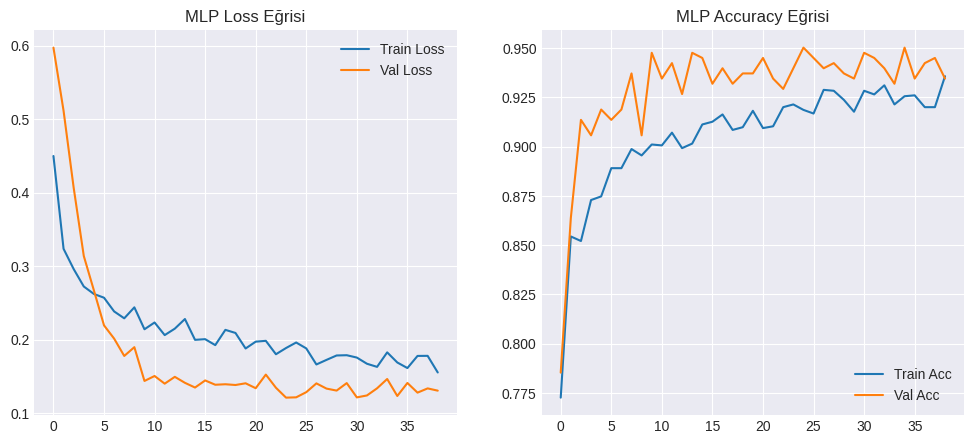

In [5]:
mlp_model, history = detector.train_mlp(X_train_s, y_train_sm.values, X_val_s, y_val.values, epochs=80, batch_size=32)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss'); plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('MLP Loss Eğrisi'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc'); plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('MLP Accuracy Eğrisi'); plt.legend()
plt.show()


---
## Bölüm 5: Tüm Gözetimli Modeller

Yukarıda çekirdek 4 model (Random Forest, XGBoost, SVM, MLP) ayrıntılı işlendi.
Bu bölümde models_trained.txt'deki 23 gözetimli modelin tamamı, aynı SMOTE'lu ve
ölçeklenmiş eğitim verisiyle eğitilir; sonraki bölümde hepsi birlikte değerlendirilir.

In [6]:
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression as _LR

# SupervisedAnomalyDetector ile eğitilen klasik / topluluk modelleri (RF, XGBoost,
# SVM, MLP zaten Bölüm 2-4'te eğitildi):
detector.train_extra_trees(X_train_s, y_train_sm)
detector.train_xgbod(X_train_s, y_train_sm)
detector.train_gradient_boosting(X_train_s, y_train_sm)
detector.train_hist_gradient_boosting(X_train_s, y_train_sm)
detector.train_adaboost(X_train_s, y_train_sm)
detector.train_bagging(X_train_s, y_train_sm)
detector.train_decision_tree(X_train_s, y_train_sm)
detector.train_knn(X_train_s, y_train_sm)
detector.train_lsvc(X_train_s, y_train_sm)
detector.train_logistic_regression(X_train_s, y_train_sm)
detector.train_ridge(X_train_s, y_train_sm)
detector.train_sgd(X_train_s, y_train_sm)
detector.train_lda(X_train_s, y_train_sm)
detector.train_qda(X_train_s, y_train_sm)
detector.train_naive_bayes(X_train_s, y_train_sm)
detector.train_voting(X_train_s, y_train_sm)

# Detector dışı (train_all_models.py ile aynı yapılandırma): LightGBM, CatBoost, Stacking
detector.models['LightGBM'] = lgb.LGBMClassifier(n_estimators=200, random_state=42, verbose=-1).fit(X_train_s, y_train_sm)
detector.models['CatBoost'] = CatBoostClassifier(iterations=200, random_state=42, verbose=0).fit(X_train_s, y_train_sm)
detector.models['Stacking Ensemble'] = StackingClassifier(
    estimators=[(n, detector.models[n]) for n in ['RandomForest', 'LogisticRegression', 'KNN']],
    final_estimator=_LR(max_iter=500), cv=3, n_jobs=-1).fit(X_train_s, y_train_sm)

print(f"Eğitilen gözetimli model sayısı: {len(detector.models)}")
print(", ".join(detector.models.keys()))

Extra Trees eğitiliyor...


XGBOD eğitiliyor...


Gradient Boosting eğitiliyor...


HistGradientBoosting eğitiliyor...


AdaBoost eğitiliyor...


Bagging eğitiliyor...


Decision Tree eğitiliyor...
KNN (k=15) eğitiliyor...
Linear SVC eğitiliyor...
Logistic Regression eğitiliyor...
Ridge Classifier eğitiliyor...
SGD Classifier (log-loss) eğitiliyor...
LDA (Linear Discriminant Analysis) eğitiliyor...
QDA (Quadratic Discriminant Analysis) eğitiliyor...
Gaussian Naive Bayes eğitiliyor...
Voting Ensemble (soft) eğitiliyor...


Eğitilen gözetimli model sayısı: 23
RandomForest, XGBoost, SVM, MLP, ExtraTrees, XGBOD, GradientBoosting, HistGradientBoosting, AdaBoost, Bagging, DecisionTree, KNN, LSVC, LogisticRegression, Ridge, SGD, LDA, QDA, NaiveBayes, Voting Ensemble, LightGBM, CatBoost, Stacking Ensemble


---
## Bölüm 6: Değerlendirme (Tüm 23 Model)

In [7]:
def _scores(model, name):
    """Skor (AUC için) + ikili tahmin. Bazı modeller predict_proba'yı (n,) veya (n,1)
    döndürebilir ya da hiç olasılık vermez; bu yüzden boyut-güvenli ele alınır."""
    import numpy as _np
    if name == 'MLP':
        prob = _np.asarray(model.predict(X_test_s, verbose=0)).ravel()
        return prob, (prob >= 0.5).astype(int)
    pred = model.predict(X_test_s)                       # modelin kendi ikili kararı
    if hasattr(model, 'predict_proba'):
        pr = _np.asarray(model.predict_proba(X_test_s))
        prob = pr[:, 1] if (pr.ndim == 2 and pr.shape[1] > 1) else pr.ravel()
    elif hasattr(model, 'decision_function'):
        prob = _np.asarray(model.decision_function(X_test_s)).ravel()
    else:
        prob = _np.asarray(pred, dtype=float)
    return prob, pred

demo_metrics = {}
for name, model in detector.models.items():
    prob, pred = _scores(model, name)
    demo_metrics[name] = compute_metrics(y_test.values, pred, prob)

results_df = metrics_table(demo_metrics, sort_by='AUC_PR')
print(f"Tüm gözetimli modeller ({len(demo_metrics)}) — resmi Ψ (529 segment), AUC_PR sıralı:")
display(results_df[BENCHMARK_METRICS].style.background_gradient(cmap='Blues').format('{:.4f}'))

Tüm gözetimli modeller (23) — resmi Ψ (529 segment), AUC_PR sıralı:


,Accuracy,Precision,Recall,F1,MCC,AUC_ROC,AUC_PR
CatBoost,0.9565,0.9018,0.8938,0.8978,0.8702,0.9768,0.9503
Bagging,0.9584,0.9505,0.8496,0.8972,0.8734,0.9715,0.9450
XGBoost,0.9565,0.9167,0.8761,0.8959,0.8688,0.9742,0.9450
Stacking Ensemble,0.9603,0.9259,0.8850,0.9050,0.8803,0.9752,0.9443
LightGBM,0.9622,0.9346,0.8850,0.9091,0.8858,0.9692,0.9405
HistGradientBoosting,0.9527,0.8860,0.8938,0.8899,0.8598,0.9702,0.9391
RandomForest,0.9565,0.9245,0.8673,0.8950,0.8683,0.9655,0.9371
Voting Ensemble,0.9376,0.8390,0.8761,0.8571,0.8176,0.9697,0.9321
MLP,0.9263,0.7937,0.8850,0.8368,0.7913,0.9657,0.9207
GradientBoosting,0.9168,0.7851,0.8407,0.8120,0.7594,0.9613,0.9192


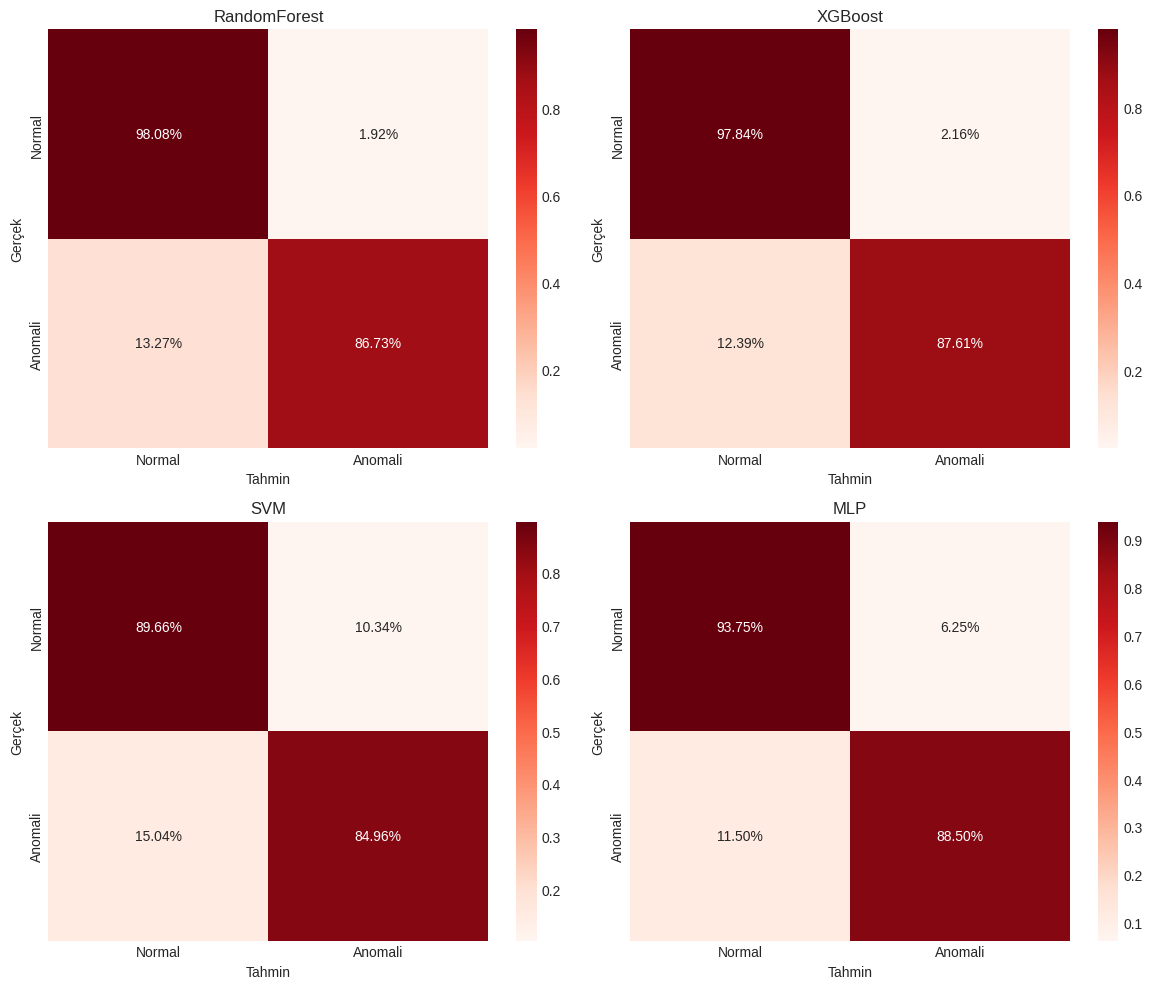

In [8]:
# Confusion matrisleri yalnız çekirdek 4 model için (okunabilirlik)
fig, axes = plt.subplots(2, 2, figsize=(12, 10)); axes = axes.flatten()
for i, name in enumerate(['RandomForest', 'XGBoost', 'SVM', 'MLP']):
    m = detector.models[name]
    yp = (m.predict(X_test_s, verbose=0) >= 0.5).astype(int).flatten() if name == 'MLP' else m.predict(X_test_s)
    cm = confusion_matrix(y_test, yp, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Reds', ax=axes[i], xticklabels=['Normal','Anomali'], yticklabels=['Normal','Anomali'])
    axes[i].set_title(name); axes[i].set_xlabel('Tahmin'); axes[i].set_ylabel('Gerçek')
plt.tight_layout(); plt.show()

---
## Bölüm 7: ROC Eğrisi (Çekirdek Modeller)

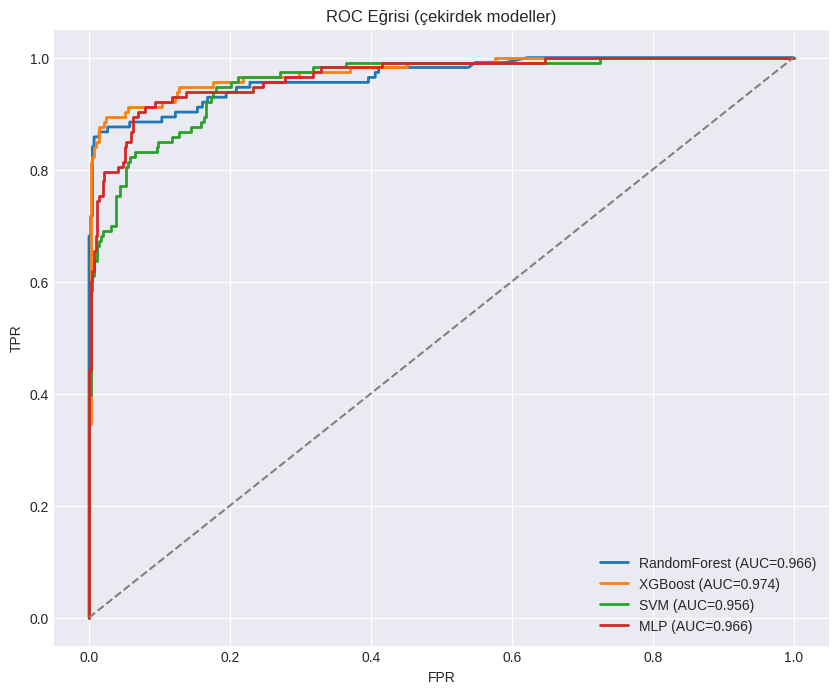

In [9]:
plt.figure(figsize=(10, 8))
for name in ['RandomForest', 'XGBoost', 'SVM', 'MLP']:
    model = detector.models[name]
    yp = model.predict(X_test_s, verbose=0).flatten() if name == 'MLP' else (model.predict_proba(X_test_s)[:,1] if hasattr(model,'predict_proba') else model.decision_function(X_test_s))
    fpr, tpr, _ = roc_curve(y_test, yp); ra = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={ra:.3f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Eğrisi (çekirdek modeller)'); plt.legend(loc='lower right')
plt.show()

---
## Bölüm 8: Kaydetme

Yukarıda models_trained.txt'deki 23 gözetimli modelin tamamı gösterim amacıyla eğitilip
resmi Ψ üzerinde değerlendirildi. Kanonik (kaydedilen) artefaktlar ve nihai karşılaştırma
`train_all_models.py` ile üretilir, NB06'da raporlanır.

---
## Bölüm 9: Derin Sıralı Modeller - Ham Telemetri Sinyali

Yukarıdaki gözetimli modeller 18 elle-üretilmiş ESA özelliğini girdi alır. Bu bölümdeki 2 derin model (CNN1D ve TCN) ise her segmentin HAM telemetri sinyalini girdi alır. Veri `data/raw/segments.csv` dosyasından okunur, per-kanal standardize edilir (ortalama ve std yalnız eğitim segmentlerinden, leakage yok), zaman-sıralı olarak L=256 uzunluğuna pad veya truncate edilir. Böylece konvolüsyonel mimariler gerçek zamansal dinamiği modeller; bu, 18 özelliğin sözde-dizi olarak ele alındığı kurguya kıyasla metodolojik olarak doğru girdidir. Her iki model sigmoid çıkışlı ikili sınıflandırıcı olduğu için gözetimlidir ve bu notebooktadır. Resmi split (T=1594 eğitim havuzu, Ψ=529 test) ve aynı 7 zorunlu metrik kullanılır. Metrikler `reports/metrics/deep_sequence_comparison.json` dosyasına yazılır ve NB06'da tabular modellerle birlikte sunulur.

Not: Tekrarlayan ve attention mimarileri (LSTM, GRU, Transformer) ön denemelerde bu küçük ve ağır padding'li veri üzerinde belirgin biçimde zayıf kaldığı için (GRU ve Transformer 0.5 eşiğinde çoğunluk sınıfına çöker) nihai sete dahil edilmemiştir. Ham sinyalde yalnız konvolüsyonel CNN1D ve TCN, özellik-tabanlı modellerle rekabetçidir.


In [10]:
import json, time
from sklearn.model_selection import train_test_split

SEG_PATH = '../data/raw/segments.csv'
SEQ_LEN = 256
_seg = pd.read_csv(SEG_PATH).sort_values(['segment', 'timestamp'], kind='stable')

# Per-kanal standardizasyon: ortalama/std yalnız train=1 örneklerinden (leakage-free)
_stats = _seg[_seg['train'] == 1].groupby('channel')['value'].agg(['mean', 'std'])
_gmean = _seg.loc[_seg['train'] == 1, 'value'].mean()
_gstd = _seg.loc[_seg['train'] == 1, 'value'].std() or 1.0

_meta = (_seg.groupby('segment')
         .agg(channel=('channel', 'first'), anomaly=('anomaly', 'first'), train=('train', 'first'))
         .reset_index().sort_values('segment'))
_grouped = {sid: g['value'].to_numpy() for sid, g in _seg.groupby('segment')}

Xseq = np.zeros((len(_meta), SEQ_LEN), dtype='float32')
for i, r in enumerate(_meta.itertuples(index=False)):
    if r.channel in _stats.index:
        mu, sd = _stats.loc[r.channel, 'mean'], _stats.loc[r.channel, 'std']
    else:
        mu, sd = _gmean, _gstd
    sd = sd if sd and sd > 1e-12 else 1.0
    vals = ((_grouped[r.segment].astype('float64') - mu) / sd)[:SEQ_LEN]   # uzunları kes
    Xseq[i, :len(vals)] = vals                                             # kısaları 0 ile pad et

yseq = _meta['anomaly'].to_numpy().astype(int)
_trm = _meta['train'].to_numpy() == 1
Xs_pool, ys_pool = Xseq[_trm], yseq[_trm]            # T = 1594
Xs_test, ys_test = Xseq[~_trm], yseq[~_trm]          # Ψ = 529
Xs_tr, Xs_val, ys_tr, ys_val = train_test_split(
    Xs_pool, ys_pool, test_size=0.15, random_state=42, stratify=ys_pool)
print(f"Ham sinyal dizileri: L={SEQ_LEN} | T={Xs_pool.shape} Ψ={Xs_test.shape} | Ψ anomali={ys_test.mean():.3f}")


Ham sinyal dizileri: L=256 | T=(1594, 256) Ψ=(529, 256) | Ψ anomali=0.214


In [11]:
deep_detector = SupervisedAnomalyDetector(random_state=42)
_trainers = {
    'CNN1D': deep_detector.train_cnn1d, 'TCN': deep_detector.train_tcn,
}
_OUT = '../models/deep_sequence'; os.makedirs(_OUT, exist_ok=True)
deep_metrics = {}
for _name, _trainer in _trainers.items():
    try:
        _t0 = time.time()
        _trainer(Xs_tr, ys_tr, Xs_val, ys_val, epochs=40, batch_size=32)
        _model = deep_detector.models[_name]
        _prob = _model.predict(deep_detector._reshape_seq(Xs_test), verbose=0).ravel()
        _pred = (_prob >= 0.5).astype(int)
        _ims = (time.time() - _t0) * 1000 / len(Xs_test)
        deep_metrics[_name] = compute_metrics(ys_test, _pred, _prob, inf_time_ms=_ims)
        deep_detector.save_model(_name, os.path.join(_OUT, f'{_name.lower()}_model.keras'))
    except Exception as _e:
        print(f"  {_name}: ATLANDI ({type(_e).__name__}: {_e})")

os.makedirs('../reports/metrics', exist_ok=True)
with open('../reports/metrics/deep_sequence_comparison.json', 'w') as f:
    json.dump(deep_metrics, f, indent=2)
df_deep = metrics_table(deep_metrics, sort_by='AUC_PR')
print(f"Derin sıralı modeller ({len(deep_metrics)}) — ham sinyal, resmi Ψ ({len(ys_test)} segment), AUC_PR sıralı:")
display(df_deep[BENCHMARK_METRICS].style.background_gradient(cmap='Purples').format('{:.4f}'))


1D-CNN eğitiliyor...
Epoch 1/40


 1/43 ━━━━━━━━━━━━━━━━━━━━ 33s 798ms/step - accuracy: 0.3750 - loss: 0.7780

10/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6566 - loss: 0.6052   

18/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6919 - loss: 0.5803

26/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7136 - loss: 0.5595

...

38/43 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9257 - loss: 0.1994

41/43 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9256 - loss: 0.1988

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9225 - loss: 0.1953 - val_accuracy: 0.9083 - val_loss: 0.2965


Model kaydedildi: ../models/deep_sequence/tcn_model.keras
Derin sıralı modeller (2) — ham sinyal, resmi Ψ (529 segment), AUC_PR sıralı:


,Accuracy,Precision,Recall,F1,MCC,AUC_ROC,AUC_PR
TCN,0.9168,0.9157,0.6726,0.7755,0.7389,0.9700,0.9212
CNN1D,0.9263,0.8627,0.7788,0.8186,0.7741,0.9575,0.9004


In [12]:
print("Tabular gözetimli model havuzunun tamamı train_all_models.py'de kanonik eğitilir (sonuçlar NB06'da).")
print("Derin sıralı modeller (ham sinyal) ise yalnız burada (NB04 Bölüm 6) eğitilir ve deep_sequence_comparison.json'a yazılır.")


Tabular gözetimli model havuzunun tamamı train_all_models.py'de kanonik eğitilir (sonuçlar NB06'da).
Derin sıralı modeller (ham sinyal) ise yalnız burada (NB04 Bölüm 6) eğitilir ve deep_sequence_comparison.json'a yazılır.
